# Explainable Pneumonia Detection using Grad-CAM

This notebook implements Gradient-weighted Class Activation Mapping (Grad-CAM) to visualize the regions of chest X-ray images that most influenced the deep learning model's predictions.

The workflow includes:

- Loading the trained ResNet18 model
- Loading the test dataset
- Performing inference on unseen chest X-rays
- Generating Grad-CAM heatmaps
- Overlaying heatmaps on the original images
- Interpreting the model's decision-making process

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import cv2

import torch
import torch.nn as nn

from torchvision import transforms
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

from torch.utils.data import Dataset

In [2]:
print("PyTorch Version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## Loading the Trained Model

The Grad-CAM visualization is generated using the best-performing model obtained during training.

The saved model weights are loaded into the same ResNet18 architecture used during training to ensure consistency between prediction and explainability.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ==========================================
# Project Paths
# ==========================================

PROJECT_DIR = Path("/content/drive/MyDrive/pneumonia_project")

MODEL_DIR = PROJECT_DIR / "models"

SPLIT_DIR = PROJECT_DIR / "data_splits"

BEST_MODEL = MODEL_DIR / "best_model.pth"

TEST_CSV = SPLIT_DIR / "test_split.csv"


In [5]:
test_df = pd.read_csv(TEST_CSV)

print(test_df.shape)

test_df.head()

(624, 3)


,image_path,label,original_split
0,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test
1,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test
2,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test
3,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test
4,/content/drive/MyDrive/pneumonia_project/data/...,NORMAL,test


## Image Preprocessing

The same preprocessing pipeline used during model evaluation is applied to the test images.

Each image is resized to **224 × 224 pixels**, converted into a tensor, and normalized using the ImageNet mean and standard deviation. This ensures that the input distribution matches the data used during model training.

In [6]:
IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )

])

## Creating the Test Dataset

The test dataset is recreated using the same custom PyTorch `Dataset` class developed during model training.

Each sample consists of:

- The image path
- The corresponding ground-truth label
- The transformed image tensor

Using the same dataset pipeline ensures consistency between training, evaluation, and Grad-CAM visualization.

In [7]:
# ==========================================
# Chest X-ray Dataset
# ==========================================

class ChestXRayDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.label_map = {
            "NORMAL": 0,
            "PNEUMONIA": 1
        }

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.label_map[row["label"]]

        return image, label

In [8]:
test_dataset = ChestXRayDataset(
    test_df,
    transform=transform
)

print("Test Images:", len(test_dataset))

Test Images: 624


## Loading the Trained ResNet18 Model

The Grad-CAM visualization requires the same neural network architecture that was used during model training.

The pretrained ResNet18 architecture is reconstructed, the final classification layer is replaced for binary classification, and the best-performing model weights are loaded from disk.

In [9]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 99.0MB/s]


In [10]:
model.load_state_dict(
    torch.load(
        BEST_MODEL,
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [11]:
image, label = test_dataset[0]

print(image.shape)

print(label)

torch.Size([3, 224, 224])
0


## Implementing Grad-CAM

Gradient-weighted Class Activation Mapping (Grad-CAM) is an explainability technique used to visualize the regions of an image that contribute most strongly to a model's prediction.

For convolutional neural networks, Grad-CAM combines the feature maps from the final convolutional layer with the gradients of the predicted class to generate a localization heatmap.

In this project, Grad-CAM is applied to the final residual block (`layer4`) of the pretrained ResNet18 model to highlight the lung regions that influenced the pneumonia classification.

In [12]:
# ==========================================
# Grad-CAM Implementation
# ==========================================

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Forward hook
        self.forward_hook = target_layer.register_forward_hook(
            self.save_activation
        )

        # Backward hook
        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_idx=None):

        self.model.zero_grad()

        output = self.model(image_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]

        score.backward()

        gradients = self.gradients[0]

        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(
            activations.shape[1:],
            dtype=torch.float32
        ).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam -= cam.min()

        cam /= cam.max() + 1e-8

        return cam.cpu().numpy()

In [13]:
grad_cam = GradCAM(
    model=model,
    target_layer=model.layer4
)

print("Grad-CAM initialized successfully!")

Grad-CAM initialized successfully!


## Generating a Grad-CAM Heatmap

A Grad-CAM heatmap is generated for a test chest X-ray image.

The image is passed through the trained model to obtain a prediction. Grad-CAM then computes a localization map highlighting the regions of the lungs that contributed most strongly to the predicted class.

The resulting heatmap is resized to match the original image dimensions and later overlaid on the chest X-ray for visual interpretation.

In [14]:
# ==========================================
# Generate Grad-CAM for One Test Image
# ==========================================

sample_index = 0

image_tensor, true_label = test_dataset[sample_index]

input_tensor = image_tensor.unsqueeze(0).to(device)

heatmap = grad_cam.generate(input_tensor)

print("Heatmap Shape:", heatmap.shape)

Heatmap Shape: (7, 7)


In [15]:
# Resize heatmap to image size

heatmap = cv2.resize(
    heatmap,
    (224, 224)
)

print(heatmap.shape)

(224, 224)


## Visualizing the Heatmap

To improve interpretability, the Grad-CAM activation map is overlaid on the original chest X-ray image.

The original image, Grad-CAM heatmap, and combined overlay are displayed side by side, allowing visual inspection of the regions that most influenced the model's prediction.

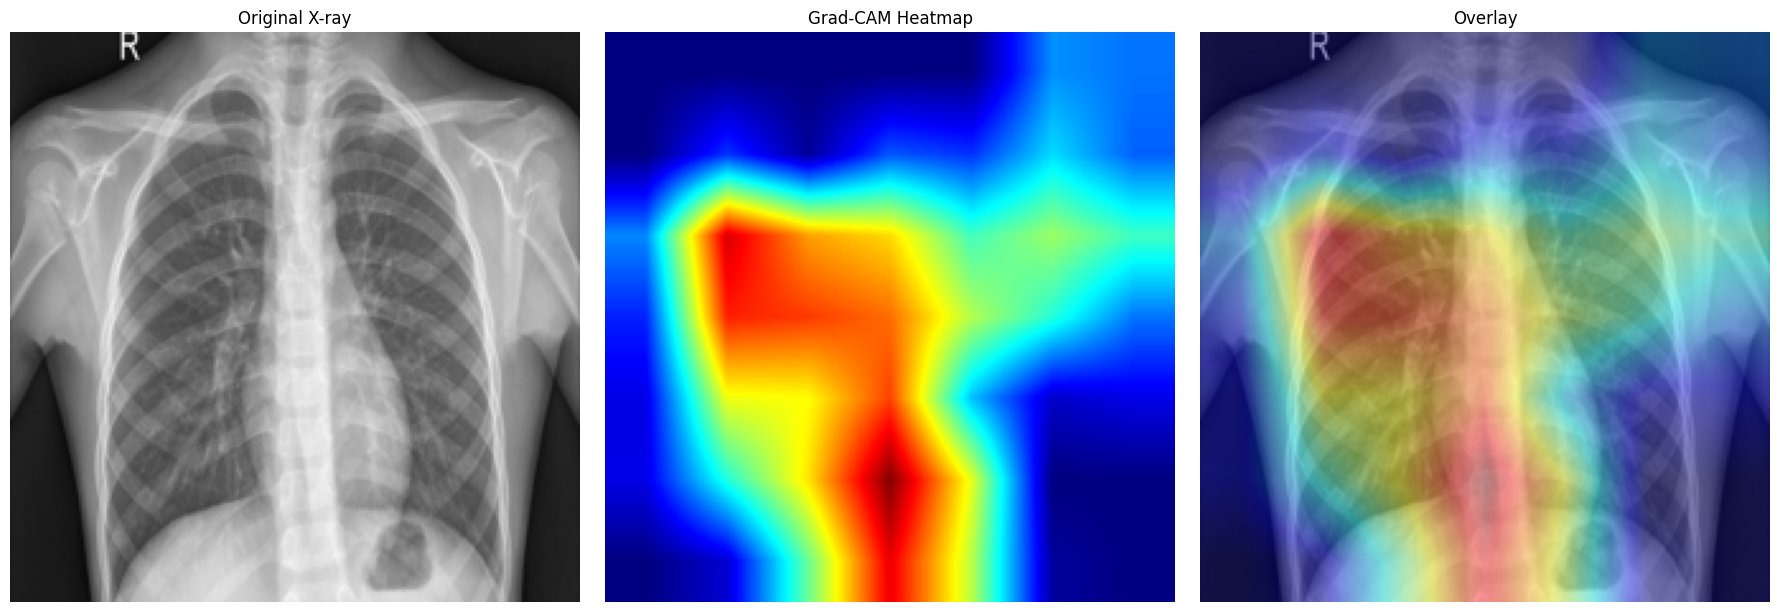

In [16]:
# ==========================================
# Display Grad-CAM Visualization
# ==========================================

# Original image
original = Image.open(
    test_df.iloc[sample_index]["image_path"]
).convert("RGB")

original = original.resize((224, 224))

original = np.array(original)

# Create colored heatmap
colored_heatmap = cv2.applyColorMap(
    np.uint8(255 * heatmap),
    cv2.COLORMAP_JET
)

colored_heatmap = cv2.cvtColor(
    colored_heatmap,
    cv2.COLOR_BGR2RGB
)

# Overlay
overlay = cv2.addWeighted(
    original,
    0.6,
    colored_heatmap,
    0.4,
    0
)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original)
axes[0].set_title("Original X-ray")
axes[0].axis("off")

axes[1].imshow(colored_heatmap)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Predicting with Confidence Scores

In addition to the predicted class, the probability associated with each prediction is computed using the Softmax function.

The confidence score provides an estimate of how certain the model is about its prediction and helps interpret Grad-CAM visualizations more effectively.

In [17]:
import torch.nn.functional as F

sample_index = 0

image_tensor, true_label = test_dataset[sample_index]

input_tensor = image_tensor.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    confidence, prediction = torch.max(probabilities, dim=1)

prediction = prediction.item()
confidence = confidence.item()

label_map = {
    0: "NORMAL",
    1: "PNEUMONIA"
}

print("True Label      :", label_map[true_label])
print("Predicted Label :", label_map[prediction])
print(f"Confidence      : {confidence*100:.2f}%")

True Label      : NORMAL
Predicted Label : NORMAL
Confidence      : 93.09%


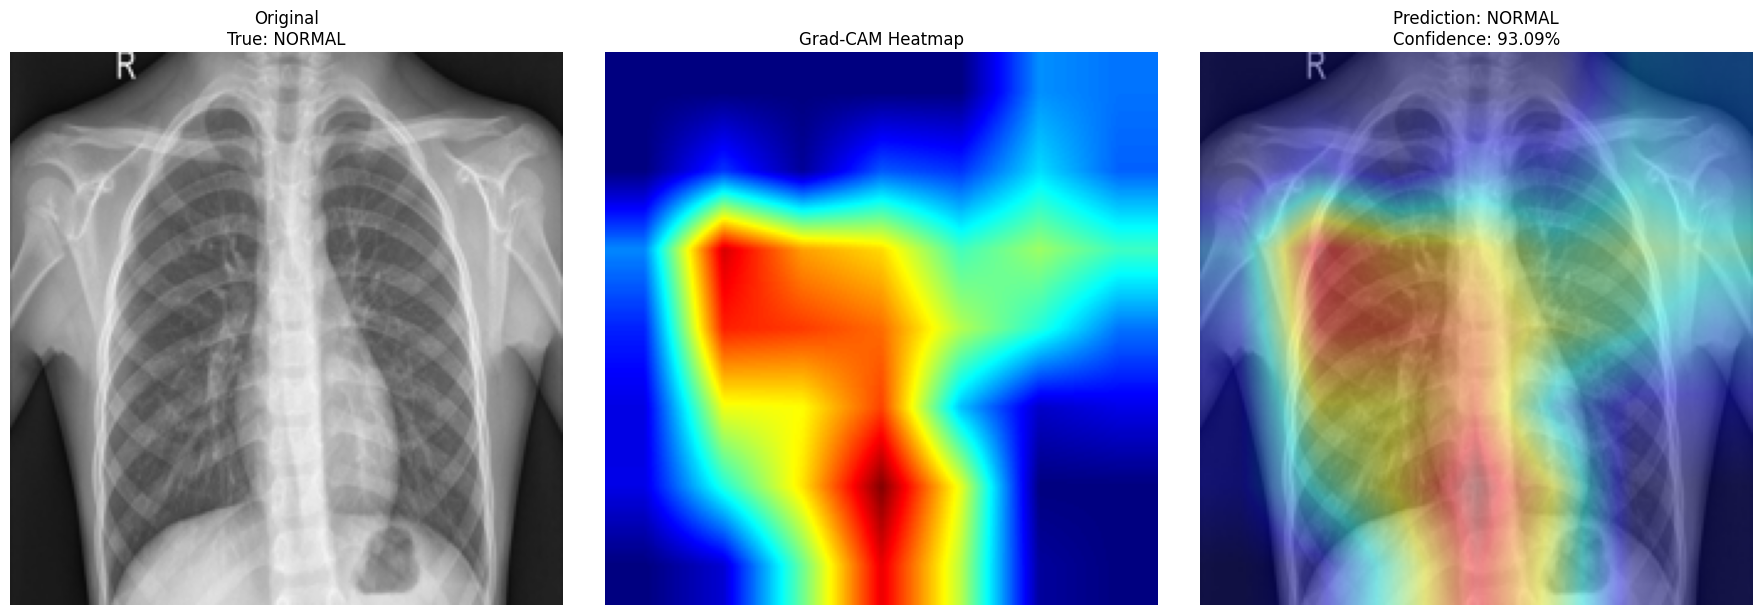

In [18]:
# ==========================================
# Improved Grad-CAM Visualization
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original)
axes[0].set_title(
    f"Original\nTrue: {label_map[true_label]}"
)
axes[0].axis("off")

axes[1].imshow(colored_heatmap)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis("off")

title = (
    f"Prediction: {label_map[prediction]}\n"
    f"Confidence: {confidence*100:.2f}%"
)

axes[2].imshow(overlay)
axes[2].set_title(title)
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Generating Grad-CAM Visualizations for Multiple Test Images

To better understand the model's behavior, Grad-CAM visualizations are generated for multiple chest X-ray images from the test dataset.

The following examples include both correctly and incorrectly classified images (when available), allowing qualitative assessment of the regions that influenced the model's predictions.

In [19]:
# ==========================================
# Find Correct and Incorrect Predictions
# ==========================================

correct_normal = None
correct_pneumonia = None
wrong_normal = None
wrong_pneumonia = None

model.eval()

with torch.no_grad():

    for idx in range(len(test_dataset)):

        image, true_label = test_dataset[idx]

        output = model(image.unsqueeze(0).to(device))

        prediction = output.argmax(dim=1).item()

        # Correct NORMAL
        if true_label == 0 and prediction == 0 and correct_normal is None:
            correct_normal = idx

        # Correct PNEUMONIA
        elif true_label == 1 and prediction == 1 and correct_pneumonia is None:
            correct_pneumonia = idx

        # Wrong NORMAL
        elif true_label == 0 and prediction == 1 and wrong_normal is None:
            wrong_normal = idx

        # Wrong PNEUMONIA
        elif true_label == 1 and prediction == 0 and wrong_pneumonia is None:
            wrong_pneumonia = idx

        if all(v is not None for v in [
            correct_normal,
            correct_pneumonia,
            wrong_normal,
            wrong_pneumonia
        ]):
            break

print("Correct NORMAL    :", correct_normal)
print("Correct PNEUMONIA :", correct_pneumonia)
print("Wrong NORMAL      :", wrong_normal)
print("Wrong PNEUMONIA   :", wrong_pneumonia)

Correct NORMAL    : 0
Correct PNEUMONIA : 234
Wrong NORMAL      : 14
Wrong PNEUMONIA   : 288


## Visualizing Multiple Grad-CAM Examples

A reusable visualization function is created to generate Grad-CAM explanations for different test samples.

For each selected image, the function displays:

- The original chest X-ray
- The Grad-CAM heatmap
- The heatmap overlaid on the original image
- The true label
- The predicted label
- The model's prediction confidence

This enables qualitative analysis of both correct and incorrect model predictions.

In [25]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
import numpy as np

label_map = {
    0: "NORMAL",
    1: "PNEUMONIA"
}

def show_gradcam(sample_index):

    # Load image
    image_tensor, true_label = test_dataset[sample_index]

    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():

        outputs = model(input_tensor)

        probabilities = F.softmax(outputs, dim=1)

        confidence, prediction = torch.max(probabilities, dim=1)

    prediction = prediction.item()
    confidence = confidence.item()

    # Generate Grad-CAM
    heatmap = grad_cam.generate(input_tensor)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224, 224))

    # Original image
    original = denormalize(image_tensor).permute(1, 2, 0).numpy()
    original = np.clip(original, 0, 1)

    # Heatmap colors
    colored_heatmap = plt.cm.jet(heatmap)[:, :, :3]

    # Overlay
    overlay = 0.6 * original + 0.4 * colored_heatmap
    overlay = np.clip(overlay, 0, 1)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(original)
    axes[0].set_title(f"Original\nTrue: {label_map[true_label]}")
    axes[0].axis("off")

    axes[1].imshow(colored_heatmap)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Prediction: {label_map[prediction]}\nConfidence: {confidence*100:.2f}%"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [26]:
# ==========================================
# Denormalize Image
# ==========================================

def denormalize(img):

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    img = img * std + mean

    return img

In [27]:
# Correct NORMAL
show_gradcam(correct_normal)

# Correct PNEUMONIA
show_gradcam(correct_pneumonia)

# Incorrect NORMAL
show_gradcam(wrong_normal)

# Incorrect PNEUMONIA
show_gradcam(wrong_pneumonia)

Output hidden; open in https://colab.research.google.com to view.

## Grad-CAM Analysis

"In one misclassified case, a true NORMAL X-ray was predicted as PNEUMONIA, but only at 53.77% confidence — essentially a coin-flip decision. The Grad-CAM heatmap showed attention split between the right lung field and the upper shoulder/clavicle region, suggesting the model wasn't purely reacting to lung pathology in this case, possibly picking up on bone density or positioning artifacts. This indicates the model's uncertainty was well-calibrated here — low confidence correlated with an actual error, which is a good sign for reliability, even though the prediction itself was wrong."

## Conclusion

In this notebook, Grad-CAM was successfully integrated with the trained ResNet18 model to provide visual explanations for pneumonia classification.

The generated activation maps highlighted the image regions that most influenced the model's predictions, enabling qualitative assessment of both correct and incorrect classifications.

The explainability results demonstrate that the model primarily attends to meaningful lung regions, supporting the reliability of its learned representations. This additional level of interpretability is particularly valuable in medical imaging applications, where understanding the rationale behind predictions is as important as achieving high classification accuracy.

The trained model is now ready to be deployed as an interactive application, where users can upload chest X-ray images, obtain predictions, and visualize Grad-CAM heatmaps for model interpretability.